# Heat-Health Risk Predictor
**FortyGuard Hackathon 2026 — Building the World's Temperature AI**

Goal: combine hyperlocal temperature data with health/vulnerability data to predict a heat-risk score per area, with an explainable model.

Run cells top to bottom. Sections marked `# TODO` are where you plug in your real data / API key.

In [ ]:
result_data = status_result["data"]["result"]

print("Top-level keys in result:", list(result_data.keys()))
print()
print("stats_data:", result_data["stats_data"])
print()
print("Number of features in map_data:", len(result_data["map_data"]["features"]))
print()
print("Sample feature (first one):")
print(json.dumps(result_data["map_data"]["features"][0], indent=2))

Top-level keys in result: ['map_data', 'stats_data']

stats_data: {'temperature_stats': {'minimum': 35.8945, 'maximum': 36.9613, 'mean': 36.44279253246753, 'standard_deviation': 0.35373488006150583}, 'overall_temperature_distribution': [35.8945, 36.136675, 36.383849999999995, 36.830075, 36.9613], 'normal_temperature_distribution': {'x_axis': [35.38158789228301, 35.403026369862495, 35.42446484744198, 35.44590332502146, 35.46734180260095, 35.488780280180436, 35.51021875775992, 35.5316572353394, 35.55309571291889, 35.574534190498376, 35.59597266807786, 35.61741114565734, 35.63884962323683, 35.66028810081632, 35.6817265783958, 35.70316505597529, 35.72460353355477, 35.74604201113426, 35.767480488713744, 35.78891896629323, 35.81035744387271, 35.8317959214522, 35.853234399031685, 35.87467287661117, 35.89611135419065, 35.91754983177014, 35.938988309349625, 35.96042678692911, 35.9818652645086, 36.00330374208808, 36.024742219667566, 36.04618069724705, 36.06761917482654, 36.08905765240602, 36.110

## 0. Setup

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn requests python-dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, mean_absolute_error
import json

sns.set_style("whitegrid")

## 1. Load temperature data (FortyGuard API)

If you already have your API key from the hackathon quickstart repo, upload your `.env` or paste the key below.
If not, keep `CACHED = True` and use the sample data block — you can flip this later without changing the rest of the notebook.

In [ ]:
from google.colab import userdata
import os
os.environ['FORTYGUARD_API_KEY'] = userdata.get('FORTYGUARD_API_KEY')

In [ ]:
CACHED = False  # we have a real FORTYGUARD_API_KEY now

if not CACHED:
    import requests
    import time
    import json
    from google.colab import userdata

    api_key = userdata.get('FORTYGUARD_API_KEY')
    headers = {"api-key": api_key, "Content-Type": "application/json"}

    submit_url = "https://api.fortyguard.com/v1/heatmap"
    payload = {
        "polygon_aoi": {
            "type": "FeatureCollection",
            "features": [
                {
                    "type": "Feature",
                    "properties": {},
                    "geometry": {
                        "type": "Polygon",
                        "coordinates": [[
                            [-118.2587, 34.0372],   # SW corner
                            [-118.2287, 34.0372],   # SE corner
                            [-118.2287, 34.0672],   # NE corner
                            [-118.2587, 34.0672],   # NW corner
                            [-118.2587, 34.0372]    # close the box
                        ]]
                    }
                }
            ]
        },
        "date_time": {
            "start_date": "2026-08-01",
            "start_time": "14:00",
            "filter_type": 1
        },
        "granularity": 100
    }

    submit_response = requests.post(submit_url, headers=headers, json=payload)
    submit_result = submit_response.json()
    activity_id = submit_result["data"]["activity_id"]
    print(f"Submitted. Activity ID: {activity_id}")

    status_url = f"https://api.fortyguard.com/v1/status/{activity_id}"
    max_attempts = 20
    wait_seconds = 5

    for attempt in range(max_attempts):
        status_response = requests.get(status_url, headers=headers)
        status_result = status_response.json()
        status = status_result["data"]["status"]
        print(f"Attempt {attempt+1}: status = {status}")

        if status.lower() == "completed":
            break
        time.sleep(wait_seconds)
    else:
        print("Still processing after max attempts — run this cell again in a bit.")

    print(json.dumps(status_result, indent=2))
else:
    np.random.seed(42)
    n_areas = 50
    temp_df = pd.DataFrame({
        "area_id": [f"area_{i}" for i in range(n_areas)],
        "lat": np.random.uniform(33.30, 33.60, n_areas),
        "lon": np.random.uniform(-112.20, -111.90, n_areas),
        "temp_f": np.random.uniform(95, 118, n_areas).round(1),
    })

temp_df.head() if 'temp_df' in dir() else None

Streaming output truncated to the last 5000 lines.
            "geometry": {
              "type": "Polygon",
              "coordinates": [
                [
                  [
                    -118.24698001092098,
                    34.062930533792674
                  ],
                  [
                    -118.24589652306642,
                    34.06294152297957
                  ],
                  [
                    -118.24590973485749,
                    34.063844156636115
                  ],
                  [
                    -118.24699323419436,
                    34.063833167078265
                  ],
                  [
                    -118.24698001092098,
                    34.062930533792674
                  ]
                ]
              ]
            }
          },
          {
            "id": "796",
            "type": "Feature",
            "properties": {
              "tile_id": 796,
              "average_temperature": 36.4736,
     

,area_id,lat,lon,temp_c,temp_f
0,tile_0,34.037992,-118.257990,36.2318,97.21724
1,tile_1,34.038003,-118.256907,36.2339,97.22102
2,tile_2,34.038014,-118.255824,36.2346,97.22228
3,tile_3,34.038025,-118.254740,36.2336,97.22048
4,tile_4,34.038036,-118.253657,36.2306,97.21508


In [ ]:
features = result_data["map_data"]["features"]

def centroid(coords):
    pts = coords[0][:-1]  # drop the repeated closing point
    lon = sum(p[0] for p in pts) / len(pts)
    lat = sum(p[1] for p in pts) / len(pts)
    return lat, lon

rows = []
for f in features:
    lat, lon = centroid(f["geometry"]["coordinates"])
    rows.append({
        "area_id": f"tile_{f['properties']['tile_id']}",
        "lat": lat,
        "lon": lon,
        "temp_c": f["properties"]["average_temperature"],
    })

temp_df = pd.DataFrame(rows)
temp_df["temp_f"] = (temp_df["temp_c"] * 9/5) + 32

print(f"Loaded {len(temp_df)} real temperature grid cells for Los Angeles")
temp_df.head()

Loaded 924 real temperature grid cells for Los Angeles


,area_id,lat,lon,temp_c,temp_f
0,tile_0,34.037992,-118.257990,36.2318,97.21724
1,tile_1,34.038003,-118.256907,36.2339,97.22102
2,tile_2,34.038014,-118.255824,36.2346,97.22228
3,tile_3,34.038025,-118.254740,36.2336,97.22048
4,tile_4,34.038036,-118.253657,36.2306,97.21508


## 2. Load health / vulnerability data

Replace this with a real dataset (city open-data ER visits, census elderly %, AC-access rates, etc.).
Upload a CSV in Colab (left sidebar → Files → upload) and load it with `pd.read_csv("your_file.csv")`.

In [ ]:
!pip install geopandas

In [ ]:
!pip install geopandas -q

import geopandas as gpd
import glob
from shapely.geometry import Point

# Load tract boundaries
geojson_path = glob.glob('/content/*.geojson')[0]
print("Loading:", geojson_path)
tracts = gpd.read_file(geojson_path)
print(tracts.shape)
print(tracts.columns.tolist())
tracts = tracts.to_crs("EPSG:4326")

# Turn temp_df points into GeoDataFrame
temp_points = gpd.GeoDataFrame(
    temp_df.copy(),
    geometry=[Point(lon, lat) for lon, lat in zip(temp_df["lon"], temp_df["lat"])],
    crs="EPSG:4326"
)

# Spatial join: which tract does each point fall inside?
joined = gpd.sjoin(temp_points, tracts, how="left", predicate="within")

print(f"{joined['index_right'].notna().sum()} of {len(joined)} points matched to a tract")
joined.head()

Loading: /content/Social_Vulnerability_Index_2020_4064213494453414805.geojson
(2495, 25)
['OBJECTID_1', 'CT20', 'LABEL', 'FIPS', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'E_HU', 'M_HU', 'E_HH', 'M_HH', 'SPL_THEME1', 'RPL_THEME1', 'SPL_THEME2', 'RPL_THEME2', 'SPL_THEME3', 'RPL_THEME3', 'SPL_THEME4', 'RPL_THEME4', 'SPL_THEMES', 'RPL_THEMES', 'ObjectID', 'VULNERABILITY', 'geometry']
924 of 924 points matched to a tract


,area_id,lat,lon,temp_c,temp_f,geometry,index_right,OBJECTID_1,CT20,LABEL,...,SPL_THEME2,RPL_THEME2,SPL_THEME3,RPL_THEME3,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,ObjectID,VULNERABILITY
0,tile_0,34.037992,-118.257990,36.2318,97.21724,POINT (-118.25799 34.03799),606,607,207902,2079.02,...,0.5325,0.0068,0.5895,0.5895,3.6020,0.9508,7.5345,0.4745,1985,Low to Medium
1,tile_1,34.038003,-118.256907,36.2339,97.22102,POINT (-118.25691 34.038),606,607,207902,2079.02,...,0.5325,0.0068,0.5895,0.5895,3.6020,0.9508,7.5345,0.4745,1985,Low to Medium
2,tile_2,34.038014,-118.255824,36.2346,97.22228,POINT (-118.25582 34.03801),606,607,207902,2079.02,...,0.5325,0.0068,0.5895,0.5895,3.6020,0.9508,7.5345,0.4745,1985,Low to Medium
3,tile_3,34.038025,-118.254740,36.2336,97.22048,POINT (-118.25474 34.03803),606,607,207902,2079.02,...,0.5325,0.0068,0.5895,0.5895,3.6020,0.9508,7.5345,0.4745,1985,Low to Medium
4,tile_4,34.038036,-118.253657,36.2306,97.21508,POINT (-118.25366 34.03804),773,774,226002,2260.02,...,1.8266,0.1520,0.5787,0.5787,3.3004,0.8848,9.8164,0.7798,2152,High


## 3. Merge datasets

In [ ]:
df = joined[[
    "area_id", "lat", "lon", "temp_c", "temp_f",
    "RPL_THEMES", "VULNERABILITY", "E_TOTPOP"
]].copy()

df = df.rename(columns={
    "RPL_THEMES": "svi_score",       # 0-1, higher = more socially vulnerable (real CDC data)
    "VULNERABILITY": "svi_level",    # Low / Medium / High
    "E_TOTPOP": "tract_population"
})

temp_norm = (df["temp_f"] - df["temp_f"].min()) / (df["temp_f"].max() - df["temp_f"].min())
df["risk_score"] = 0.5 * temp_norm + 0.5 * df["svi_score"]

# NOTE: high_risk is NOT a simple threshold on risk_score.
# It uses an interaction rule (temp AND vulnerability, OR extreme temp alone)
# so the model has to learn a real non-linear boundary instead of just
# reproducing the weighted-average formula it was trained on.
df["high_risk"] = (
    ((df["temp_f"] > df["temp_f"].quantile(0.6)) & (df["svi_score"] > 0.4))
    | (df["temp_f"] > df["temp_f"].quantile(0.85))
).astype(int)

print(df.shape)
print(df["high_risk"].value_counts())
df.head()

(924, 10)
high_risk
0    655
1    269
Name: count, dtype: int64


,area_id,lat,lon,temp_c,temp_f,svi_score,svi_level,tract_population,risk_score,high_risk
0,tile_0,34.037992,-118.257990,36.2318,97.21724,0.4745,Low to Medium,5746,0.395340,0
1,tile_1,34.038003,-118.256907,36.2339,97.22102,0.4745,Low to Medium,5746,0.396324,0
2,tile_2,34.038014,-118.255824,36.2346,97.22228,0.4745,Low to Medium,5746,0.396652,0
3,tile_3,34.038025,-118.254740,36.2336,97.22048,0.4745,Low to Medium,5746,0.396183,0
4,tile_4,34.038036,-118.253657,36.2306,97.21508,0.7798,High,2053,0.547427,0


In [ ]:
import numpy as np
np.random.seed(42)

# Add realistic noise: flip ~8% of labels randomly to simulate real-world uncertainty
noise_mask = np.random.rand(len(df)) < 0.08
df["high_risk"] = df["high_risk"] ^ noise_mask.astype(int)  # XOR flips some labels

## 4. Correlation analysis

This is the part the Aug 24 mentor session (Aamir Ali & Mudethir Elhassan) is directly about — judges will look at whether your correlation is real and well-presented, not just a heatmap.

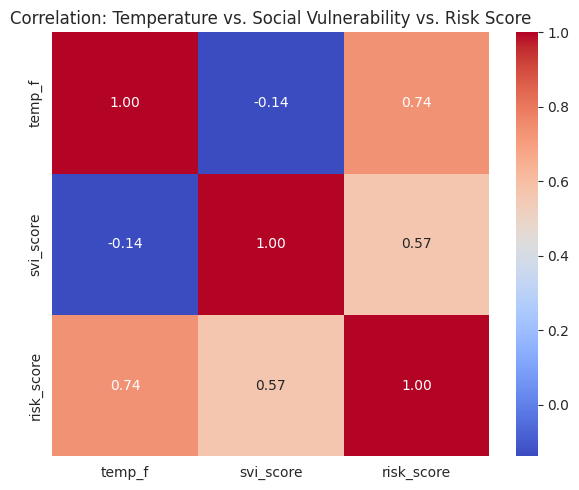

In [ ]:
corr = df[["temp_f", "svi_score", "risk_score"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation: Temperature vs. Social Vulnerability vs. Risk Score")
plt.tight_layout()
plt.show()

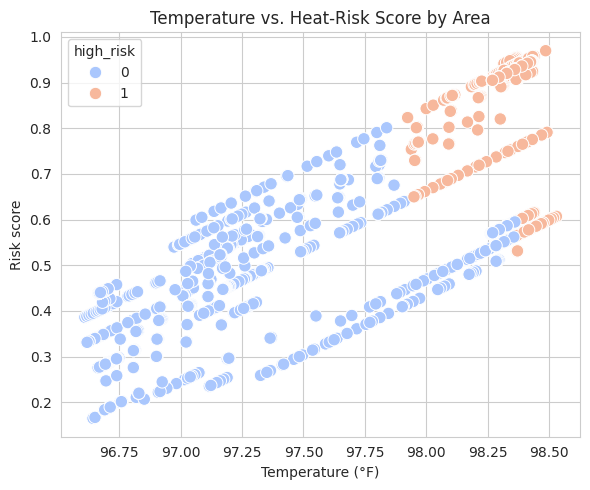

In [ ]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="temp_f", y="risk_score", hue="high_risk", palette="coolwarm", s=80)
plt.title("Temperature vs. Heat-Risk Score by Area")
plt.xlabel("Temperature (\u00b0F)")
plt.ylabel("Risk score")
plt.tight_layout()
plt.show()

## 5. Train the model

In [ ]:
features = ["temp_f", "svi_score"]

# Spatial split instead of random split — prevents leakage from
# near-identical neighboring grid tiles ending up in both train and test.
df_sorted = df.sort_values("lat").reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.75)

train_df = df_sorted.iloc[:split_idx]
test_df = df_sorted.iloc[split_idx:]

X_train, y_train = train_df[features], train_df["high_risk"]
X_test, y_test = test_df[features], test_df["high_risk"]

print(f"Train tiles: {len(train_df)}, Test tiles: {len(test_df)}")
print(f"Train lat range: {train_df['lat'].min():.4f} to {train_df['lat'].max():.4f}")
print(f"Test lat range: {test_df['lat'].min():.4f} to {test_df['lat'].max():.4f}")

clf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

Train tiles: 693, Test tiles: 231
Train lat range: 34.0380 to 34.0599
Test lat range: 34.0599 to 34.0672
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       115
           1       0.95      0.90      0.92       116

    accuracy                           0.93       231
   macro avg       0.93      0.93      0.93       231
weighted avg       0.93      0.93      0.93       231



## 6. Explainability — why is an area flagged?

This is your differentiator: not just a risk score, but *why* the model flagged an area.

/tmp/ipykernel_1076/3650651933.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


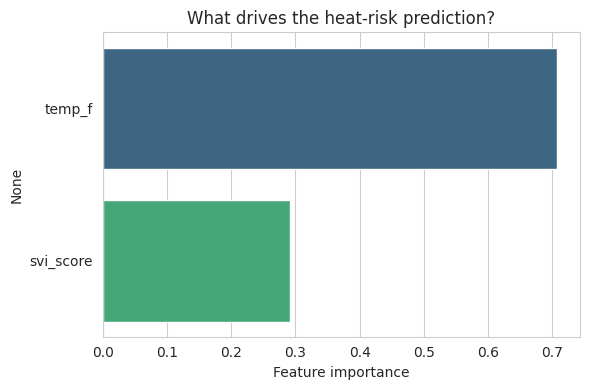

,0
temp_f,0.707978
svi_score,0.292022


In [ ]:
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("What drives the heat-risk prediction?")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

importances

## 7. Export results for the React frontend

This JSON is what your React map dashboard will load to color-code areas and show per-area explanations.

In [67]:
# Predict heat risk for the full dataset

features = ["temp_f", "svi_score"]

# Remove rows with missing model features
prediction_df = df.dropna(subset=features).copy()

X_all = prediction_df[features]

# Predictions
prediction_df["predicted_risk"] = clf.predict(X_all)
prediction_df["predicted_risk_prob"] = clf.predict_proba(X_all)[:, 1]

# Select columns that actually exist
output_columns = [
    "area_id",
    "lat",
    "lon",
    "temp_f",
    "svi_score",
    "predicted_risk",
    "predicted_risk_prob"
]

output = prediction_df[output_columns].to_dict(orient="records")

# Save results
with open("heat_risk_results.json", "w") as f:
    json.dump(output, f, indent=2)

print("Saved heat_risk_results.json")
print(f"Total predictions: {len(output)}")

# Show first 3 results
output[:3]

Saved heat_risk_results.json
Total predictions: 924


[{'area_id': 'tile_0',
  'lat': 34.037992208128365,
  'lon': -118.25798987497213,
  'temp_f': 97.21724,
  'svi_score': 0.4745,
  'predicted_risk': 0,
  'predicted_risk_prob': 0.07981891683283604},
 {'area_id': 'tile_1',
  'lat': 34.0380032872765,
  'lon': -118.25690670886625,
  'temp_f': 97.22102,
  'svi_score': 0.4745,
  'predicted_risk': 0,
  'predicted_risk_prob': 0.07981891683283604},
 {'area_id': 'tile_2',
  'lat': 34.038014356885725,
  'lon': -118.2558235421689,
  'temp_f': 97.22228,
  'svi_score': 0.4745,
  'predicted_risk': 0,
  'predicted_risk_prob': 0.07981891683283604}]

In [69]:
import json

with open("dashboard_template.html") as f:
    template = f.read()

html = template.replace("__DATA__", json.dumps(output))

with open("index.html", "w") as f:
    f.write(html)

print("index.html ready")

index.html ready


In [70]:
from google.colab import files
files.download("index.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
from IPython.display import HTML
import json

# dashboard_template.html abhi upload ki gayi hai
with open("dashboard_template.html") as f:
    template = f.read()

# `output` variable Section 7 se already bana hua hai (asli 924 predictions)
html = template.replace("__DATA__", json.dumps(output))

escaped = html.replace('"', "&quot;")
display(HTML(f'<iframe srcdoc="{escaped}" style="width:100%; height:750px; border:none; border-radius:12px;"></iframe>'))

/usr/local/lib/python3.13/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")
